<div style="background-color:#EAF4EC; padding:20px; border-radius:10px;">

<h2 style="color:#2F6F4E; text-align:center; margin-bottom:5px;">
Explainable AI: Interpreting Governance Drivers
</h2>

<h4 style="color:#2F6F4E; text-align:center; margin-top:0;">
Master Thesis – ESG Governance Indicators (EU-27)
</h4>

<p style="font-size:14px; color:#2F6F4E;">
This notebook applies <strong>Explainable AI (XAI) techniques</strong> to interpret the drivers behind the
machine learning models used in the forecasting and clustering stages of the analysis.
</p>

<p style="font-size:14px; color:#2F6F4E;">
Using methods such as <strong>feature importance and SHAP values</strong>, the analysis identifies which
governance indicators most strongly influence model predictions and cluster membership.
</p>

<p style="font-size:14px; color:#2F6F4E;">
These explanations help clarify <strong>why countries belong to specific governance typologies</strong>
and provide insights into the institutional factors driving <strong>cluster differentiation and
potential transitions</strong> across EU member states.
</p>

</div>

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
1. Imports and Setup
</h2>
</div>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

In [2]:
# Visual style
BG = "#EAF4EC"
TEXT = "#2F6F4E"
GRID = "#D9E8DD"

CLUSTER_COLORS = {
    0: "#A8D5BA",
    1: "#6EBA9A",
    2: "#357A52"
}

plt.rcParams["figure.facecolor"] = BG
plt.rcParams["axes.facecolor"] = BG
plt.rcParams["savefig.facecolor"] = BG
plt.rcParams["axes.edgecolor"] = "#CCCCCC"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
2. Data Loading
</h2>
</div>

In [3]:
fuzzy_all = pd.read_csv("../../data/processed/fuzzy_all.csv")
df_xy     = pd.read_csv("../../data/processed/df_xy_pivoted.csv")

INDICATOR_COLS = [c for c in df_xy.columns
                  if c not in ["Country Code", "Country Name", "year"]]

print("fuzzy_all:", fuzzy_all.shape)   # (837, 9)
print("df_xy:    ", df_xy.shape)       # (837, 19)
print("Indicators:", len(INDICATOR_COLS))

fuzzy_all: (837, 9)
df_xy:     (837, 19)
Indicators: 16


In [4]:
# fuzzy_all tem: Country Code, year, Cluster (e membership cols)
# df_xy tem: Country Code, year, + 15 indicadores
df_clean = fuzzy_all[["Country Code", "Country Name", "year", "Cluster"]].merge(
    df_xy,
    on=["Country Code", "year"],
    how="inner"
)

# Verificar que os cluster labels batem certo com o clustering notebook:
# Cluster 0 = Weak Institutional Framework
# Cluster 1 = Transitional Governance
# Cluster 2 = Consolidated Governance
print("Cluster distribution:")
print(df_clean["Cluster"].value_counts().sort_index())
print("\ndf_clean shape:", df_clean.shape)

Cluster distribution:
Cluster
0    273
1    293
2    271
Name: count, dtype: int64

df_clean shape: (837, 21)


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
3. Data Preparation & Merge</h2>
</div>

In [5]:
# Confirmar cluster labels — usa Country Code (não depende de Country Name)
check = df_clean[df_clean["year"] == 2030][["Country Code", "Cluster"]]\
        .sort_values("Cluster")

print("Cluster 0 — deve ser Weak (ex: BGR, GRC, HUN):")
print(check[check["Cluster"] == 0]["Country Code"].tolist())

print("\nCluster 1 — deve ser Transitional (ex: DEU, FRA, PRT):")
print(check[check["Cluster"] == 1]["Country Code"].tolist())

print("\nCluster 2 — deve ser Consolidated (ex: DNK, FIN, SWE):")
print(check[check["Cluster"] == 2]["Country Code"].tolist())

Cluster 0 — deve ser Weak (ex: BGR, GRC, HUN):
['AUT', 'NLD', 'LUX', 'IRL', 'FIN', 'EST', 'SWE', 'DEU', 'BEL', 'DNK']

Cluster 1 — deve ser Transitional (ex: DEU, FRA, PRT):
['ESP', 'PRT', 'SVN', 'LTU', 'FRA', 'CZE']

Cluster 2 — deve ser Consolidated (ex: DNK, FIN, SWE):
['CYP', 'ITA', 'GRC', 'BGR', 'LVA', 'MLT', 'POL', 'ROU', 'SVK', 'HRV', 'HUN']


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
4. Feature Engineering & Scaling </h2>
</div>

In [6]:
# Excluir explicitamente todas as colunas não-numéricas e de metadata
NON_FEATURES = ["Cluster", "Cluster_Global", "Country Code", "Country Name", 
                 "country_code", "country_name", "Year", "year"]

# Só manter colunas numéricas que não sejam metadata
FEATURES = [c for c in df_clean.columns 
            if c not in NON_FEATURES 
            and df_clean[c].dtype in [np.float64, np.float32, np.int64, np.int32]]
# Colunas base — só inclui Country Name se existir
base_cols = ["Country Code", "year", "Cluster"]
if "Country Name" in df_clean.columns:
    base_cols.insert(1, "Country Name")

df_model = df_clean[base_cols + FEATURES].copy()

X = df_model[FEATURES].astype(float)
y = df_model["Cluster"].astype(int).values

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

feature_names_clean = [
    c.replace(".ZS", "").replace(".", " ").replace("_", " ").upper()
    for c in FEATURES
]

print(f"Features: {len(FEATURES)}")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"Columns in df_model: {list(df_model.columns[:6])}...")

Features: 15
X_scaled shape: (837, 15)
y shape: (837,)
Columns in df_model: ['Country Code', 'year', 'Cluster', 'CC.EST', 'GB.XPD.RSDV.GD.ZS', 'GE.EST']...


In [7]:
cluster_titles = {
    0: "Cluster 0 — Weak Institutional Framework",
    1: "Cluster 1 — Transitional Governance",
    2: "Cluster 2 — Consolidated Governance"}

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
5. XGBoost Classifier
</h2>
</div>

In [8]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_scaled, y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
y_pred = model.predict(X_scaled)

print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(
    y, y_pred,
    target_names=list(cluster_titles.values())
))

CV Accuracy: 0.952 ± 0.008

                                          precision    recall  f1-score   support

Cluster 0 — Weak Institutional Framework       1.00      1.00      1.00       273
     Cluster 1 — Transitional Governance       1.00      1.00      1.00       293
     Cluster 2 — Consolidated Governance       1.00      1.00      1.00       271

                                accuracy                           1.00       837
                               macro avg       1.00      1.00      1.00       837
                            weighted avg       1.00      1.00      1.00       837



<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
6. Classification Performance: Confusion Matrix
</h2>
</div>

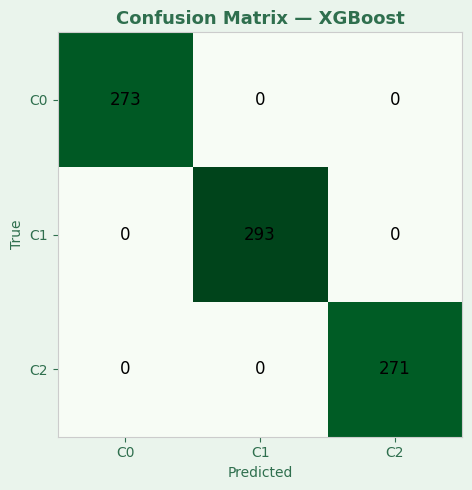

In [9]:
cm = confusion_matrix(y, y_pred)
labels = [f"C{i}" for i in range(3)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — XGBoost", color=TEXT, fontsize=13, fontweight="bold")

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
7. SHAP Explainer
</h2>
</div>

In [10]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

# Normalizar para multi-classe
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_list = shap_values

print("SHAP values computed.")
print(f"Classes: {len(shap_list)}")
print(f"Shape per class: {np.array(shap_list[0]).shape}")

SHAP values computed.
Classes: 3
Shape per class: (837, 15)


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
8. SHAP Global Feature Importance by Cluster
</h2>
</div>

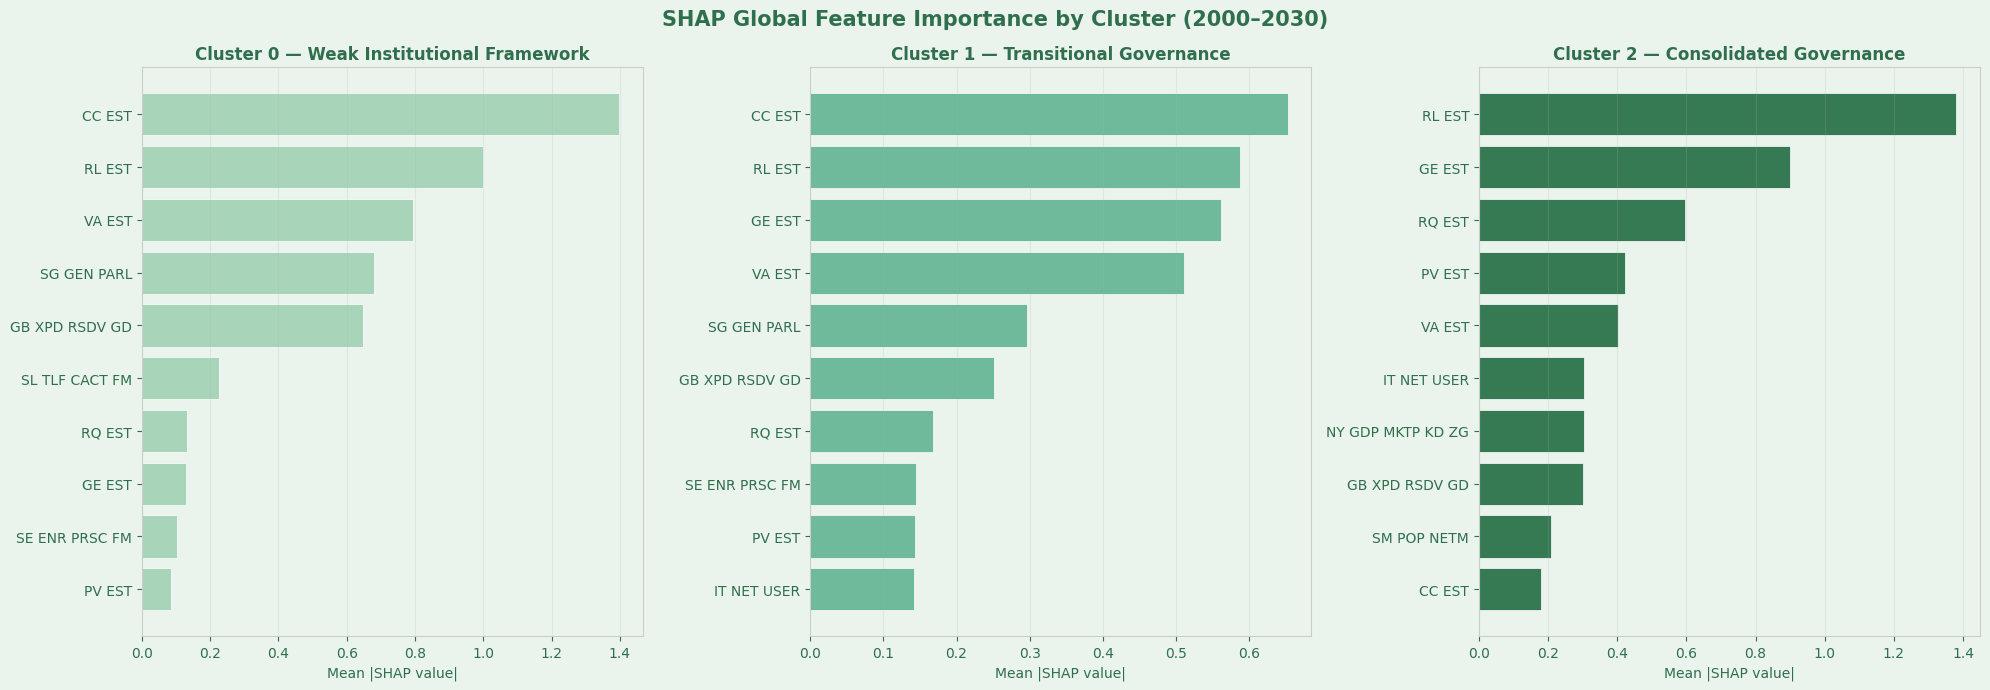

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
for i, ax in enumerate(axes):
    mean_abs_shap = np.abs(shap_list[i]).mean(axis=0)
    order = np.argsort(mean_abs_shap)[-10:]

    ax.barh(
        [feature_names_clean[j] for j in order],
        mean_abs_shap[order],
        color=CLUSTER_COLORS[i],
        edgecolor="white", linewidth=0.5
    )
    ax.set_title(cluster_titles[i], fontsize=12, fontweight="bold", color=TEXT)
    ax.set_xlabel("Mean |SHAP value|")
    ax.grid(axis="x", alpha=0.2)

plt.suptitle("SHAP Global Feature Importance by Cluster (2000–2030)",
             fontsize=15, fontweight="bold", color=TEXT)
plt.tight_layout()
plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
9. SHAP Beeswarm — Direction of Effects
</h2>
</div>

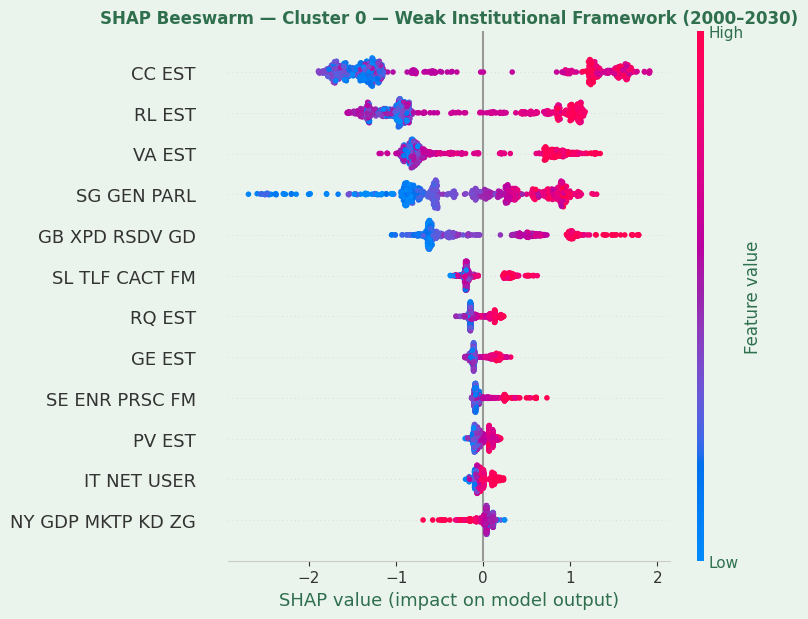

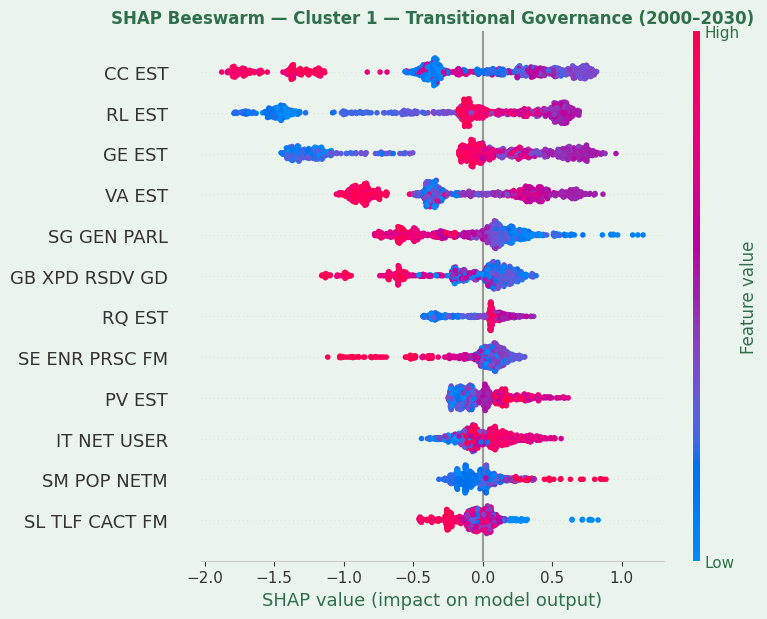

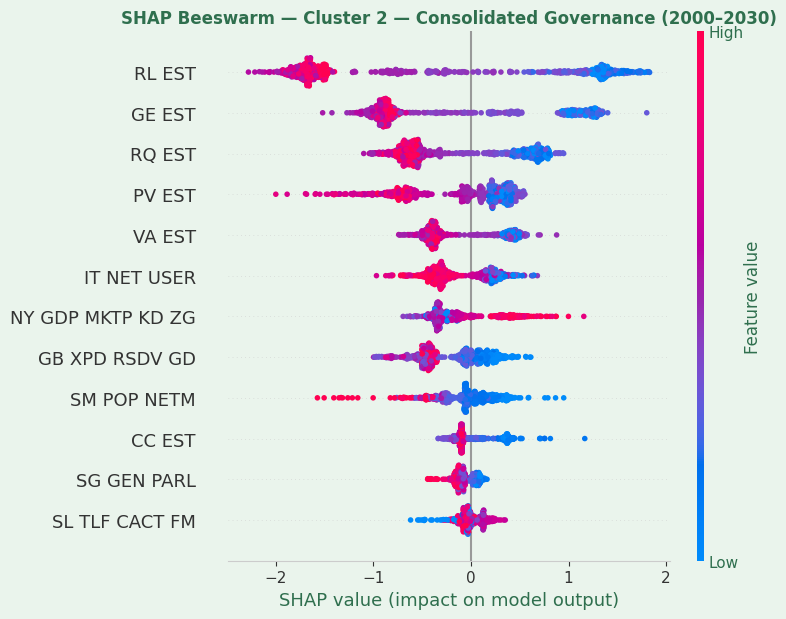

In [12]:
shap.initjs()

for i, cname in cluster_titles.items():
    plt.figure(figsize=(10, 7), facecolor=BG)
    shap.summary_plot(
        shap_list[i], X_scaled,
        feature_names=feature_names_clean,
        max_display=12, show=False, plot_type="dot"
    )
    plt.title(f"SHAP Beeswarm — {cname} (2000–2030)",
              color=TEXT, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
10. Top Drivers Table </h2>
</div>

In [13]:
top_k = 10
summary_tables = []

for i in range(3):
    mean_abs_shap = np.abs(shap_list[i]).mean(axis=0)
    order = np.argsort(mean_abs_shap)[::-1][:top_k]

    temp = pd.DataFrame({
        "Cluster":    cluster_titles[i],
        "Rank":       range(1, top_k + 1),
        "Feature":    [feature_names_clean[j] for j in order],
        "Mean_SHAP":  mean_abs_shap[order]
    })
    summary_tables.append(temp)

df_shap_ranking = pd.concat(summary_tables, ignore_index=True)
df_shap_ranking

,Cluster,Rank,Feature,Mean_SHAP
0,Cluster 0 — Weak Institutional Framework,1,CC EST,1.397130
1,Cluster 0 — Weak Institutional Framework,2,RL EST,0.998826
2,Cluster 0 — Weak Institutional Framework,3,VA EST,0.793644
3,Cluster 0 — Weak Institutional Framework,4,SG GEN PARL,0.680026
4,Cluster 0 — Weak Institutional Framework,5,GB XPD RSDV GD,0.646846
5,Cluster 0 — Weak Institutional Framework,6,SL TLF CACT FM,0.226224
6,Cluster 0 — Weak Institutional Framework,7,RQ EST,0.133208
7,Cluster 0 — Weak Institutional Framework,8,GE EST,0.129635
8,Cluster 0 — Weak Institutional Framework,9,SE ENR PRSC FM,0.103343
9,Cluster 0 — Weak Institutional Framework,10,PV EST,0.086355


<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">11. SHAP Waterfall — Country-Level Explanations
</h2>
</div>

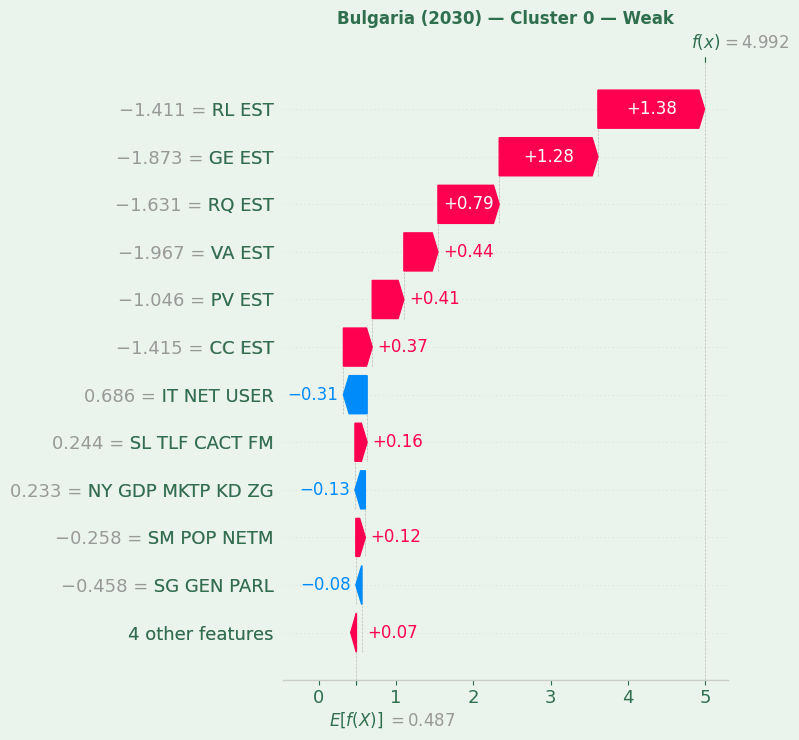

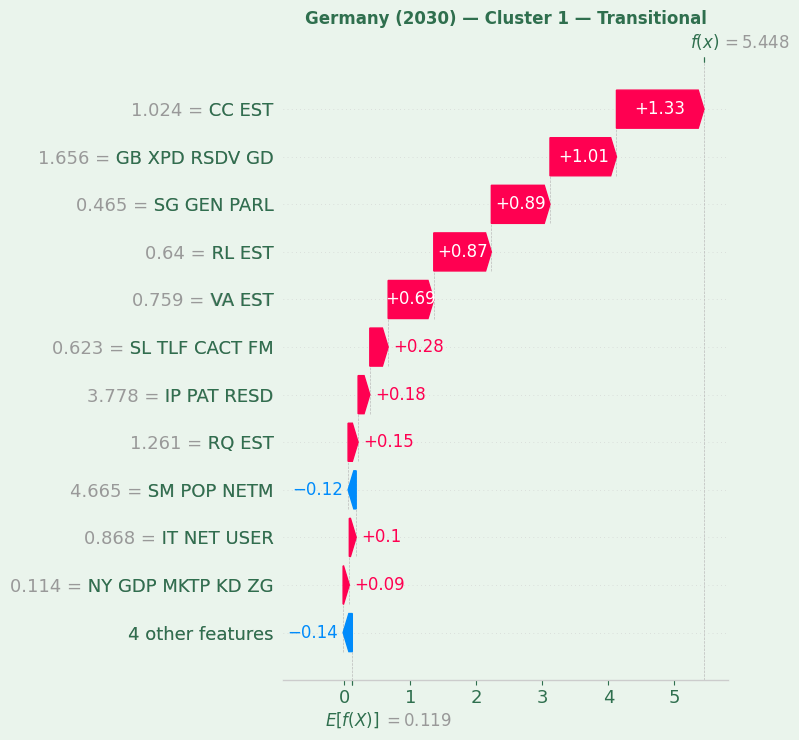

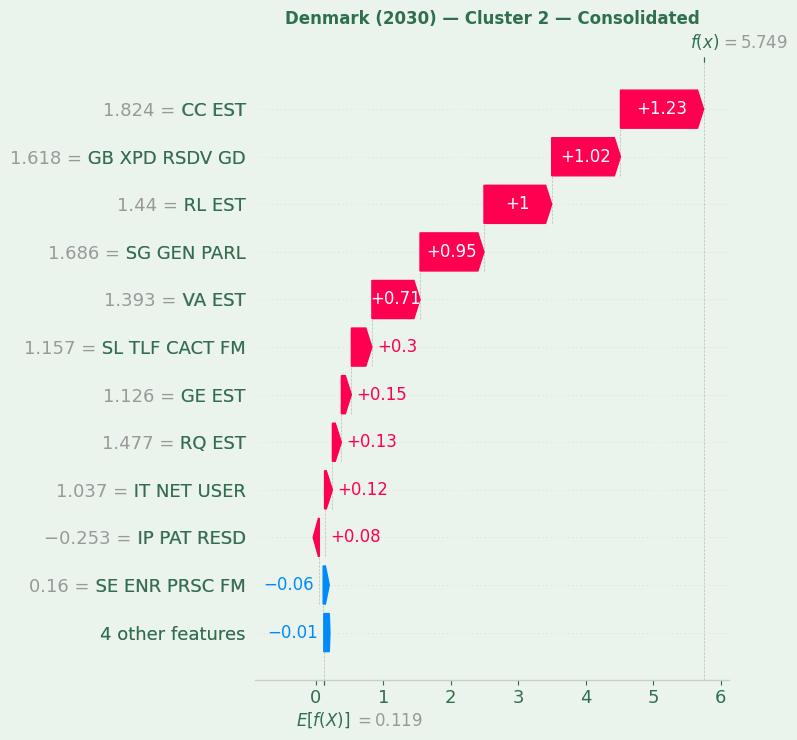

In [14]:
COUNTRIES_REPR = {
    "BGR": ("Bulgaria",  "Cluster 0 — Weak"),
    "DEU": ("Germany",   "Cluster 1 — Transitional"),
    "DNK": ("Denmark",   "Cluster 2 — Consolidated")
}
YEAR_FOCUS = 2030

for code, (name, label) in COUNTRIES_REPR.items():
    mask = (df_model["Country Code"] == code) & (df_model["year"] == YEAR_FOCUS)
    if mask.sum() == 0:
        print(f"No data for {name} in {YEAR_FOCUS}")
        continue

    idx_pos      = df_model.index.get_loc(df_model[mask].index[0])
    pred_cluster = model.predict(X_scaled[[idx_pos]])[0]

    sv = shap.Explanation(
        values=shap_list[pred_cluster][idx_pos],
        base_values=explainer.expected_value[pred_cluster],
        data=X_scaled[idx_pos],
        feature_names=feature_names_clean
    )

    plt.figure(figsize=(10, 6), facecolor=BG)
    shap.waterfall_plot(sv, max_display=12, show=False)
    plt.title(f"{name} ({YEAR_FOCUS}) — {label}",
              color=TEXT, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
12. SHAP Waterfall — Transition Countries
</h2>
</div>

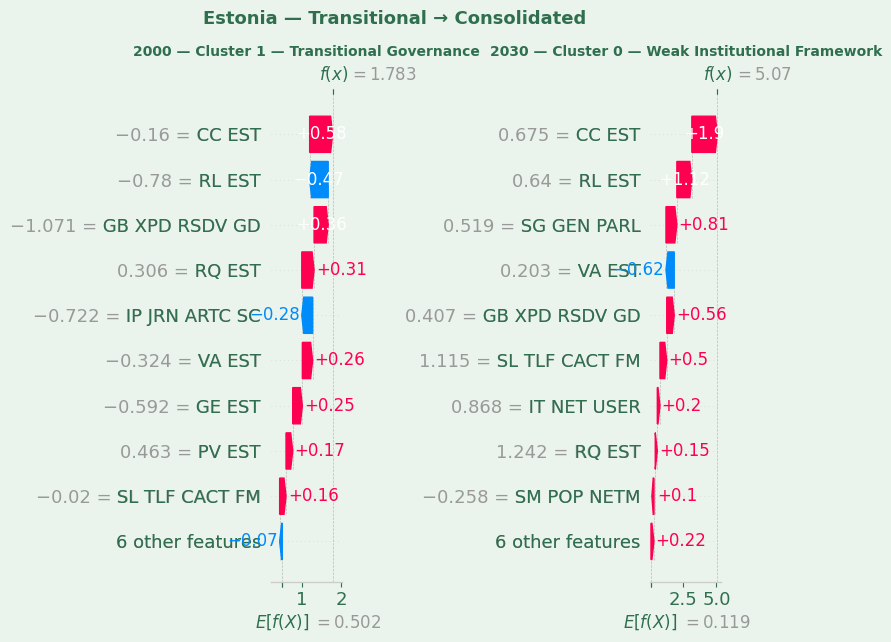

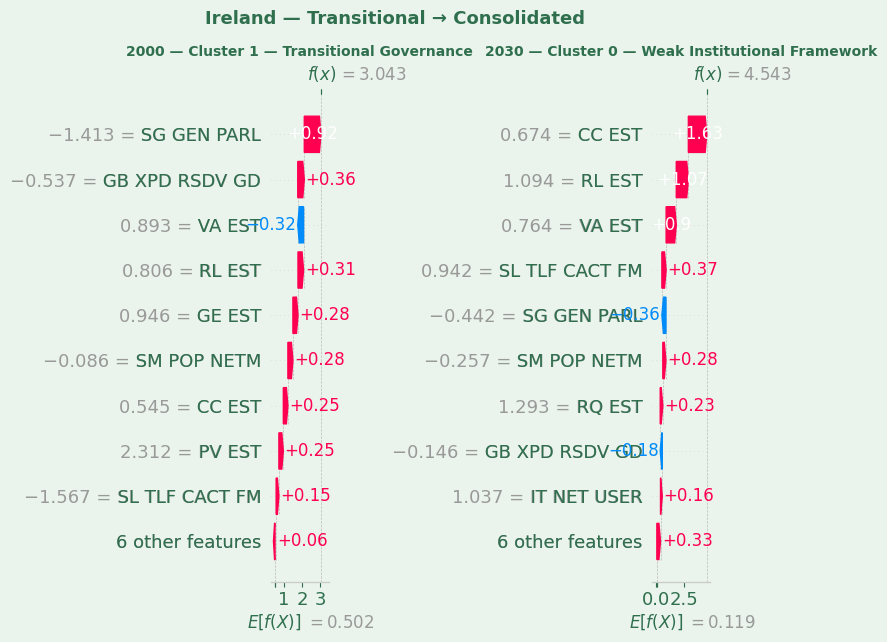

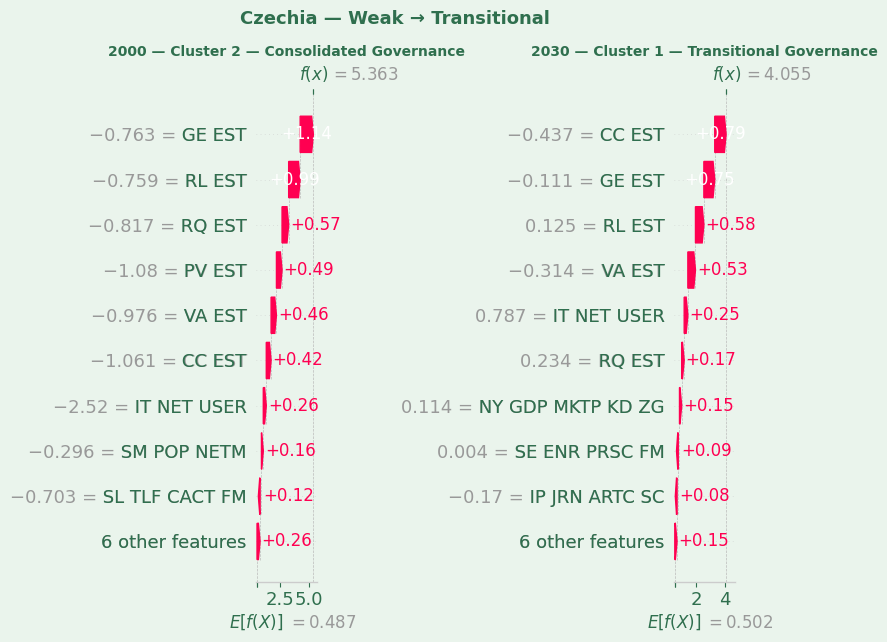

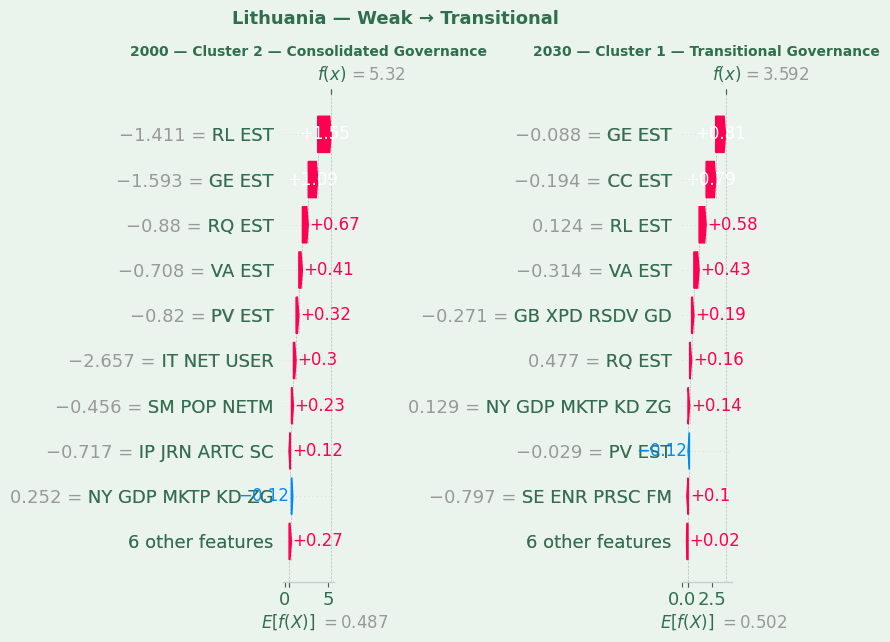

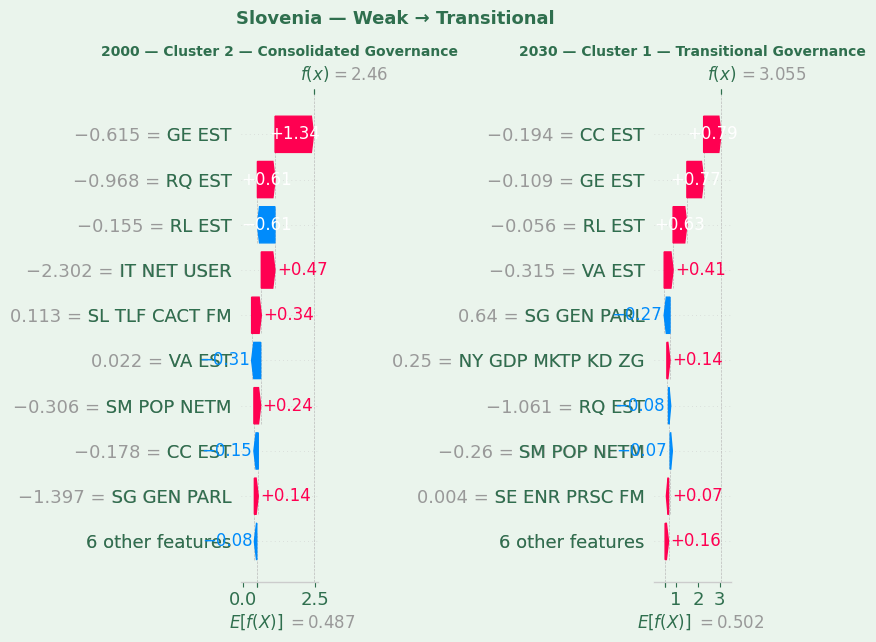

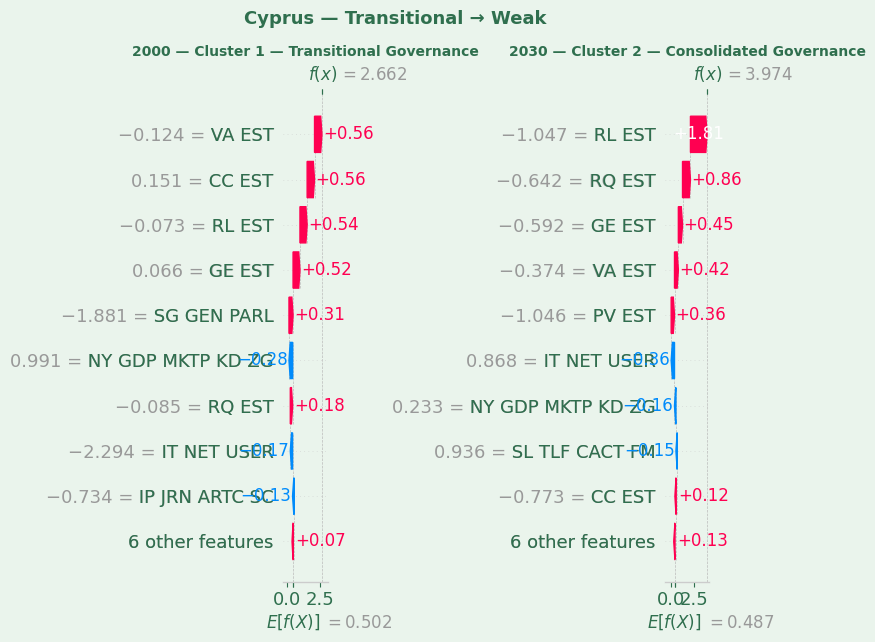

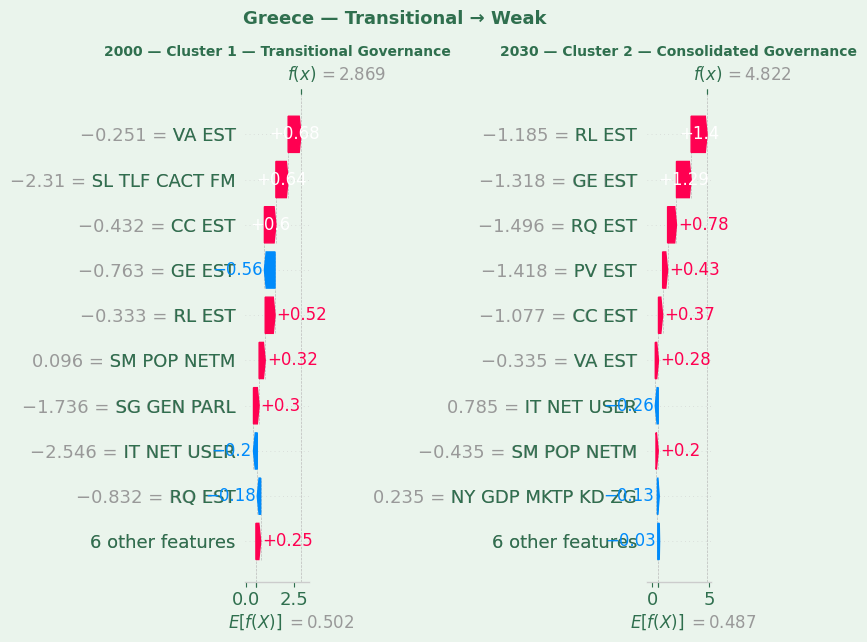

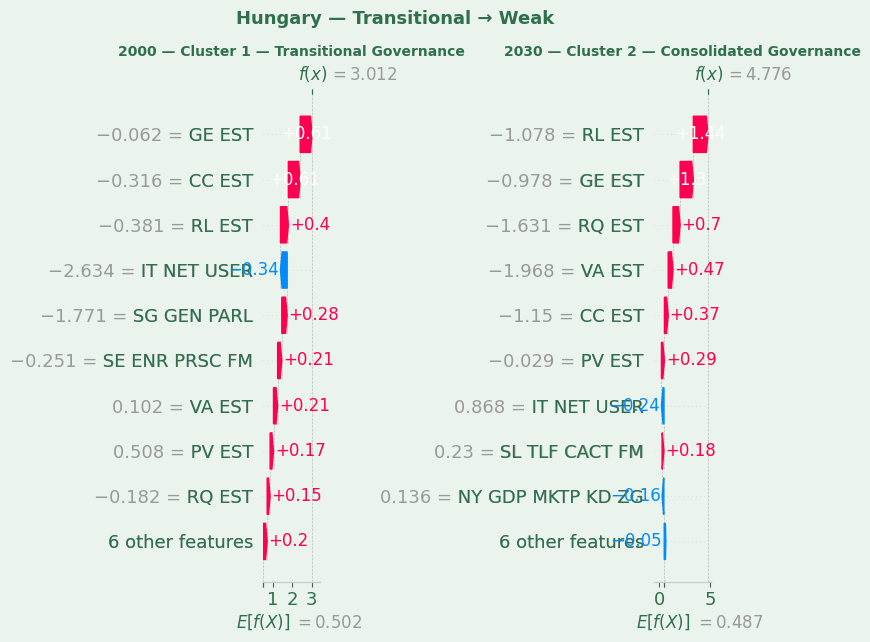

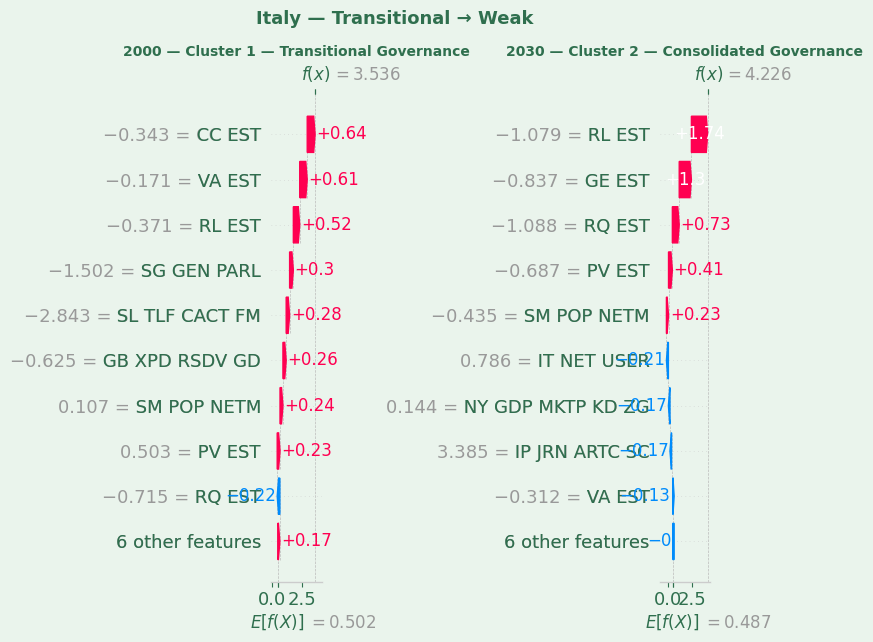

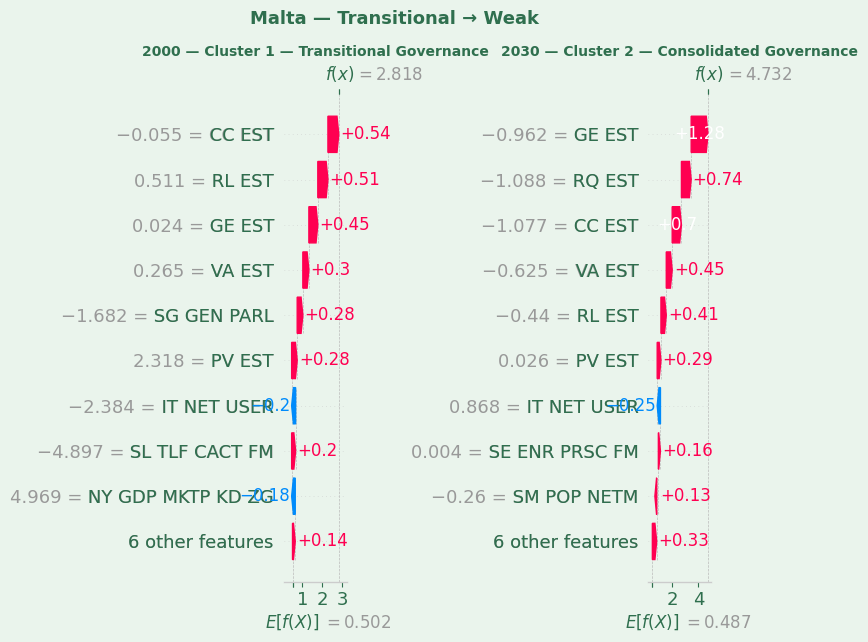

In [15]:
COUNTRIES_TRANSITION = {
    # Upward
    "EST": ("Estonia",   "Transitional → Consolidated"),
    "IRL": ("Ireland",   "Transitional → Consolidated"),
    "CZE": ("Czechia",   "Weak → Transitional"),
    "LTU": ("Lithuania", "Weak → Transitional"),
    "SVN": ("Slovenia",  "Weak → Transitional"),
    # Downward
    "CYP": ("Cyprus",    "Transitional → Weak"),
    "GRC": ("Greece",    "Transitional → Weak"),
    "HUN": ("Hungary",   "Transitional → Weak"),
    "ITA": ("Italy",     "Transitional → Weak"),
    "MLT": ("Malta",     "Transitional → Weak"),
}

for code, (name, transition) in COUNTRIES_TRANSITION.items():
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
    fig.suptitle(f"{name} — {transition}", color=TEXT, fontsize=13, fontweight="bold")

    for ax, year in zip(axes, [2000, 2030]):
        mask = (df_model["Country Code"] == code) & (df_model["year"] == year)
        if mask.sum() == 0:
            ax.set_title(f"No data for {year}")
            ax.axis("off")
            continue

        idx_pos = df_model.index.get_loc(df_model[mask].index[0])
        pred_cluster = model.predict(X_scaled[[idx_pos]])[0]

        sv = shap.Explanation(
            values=shap_list[pred_cluster][idx_pos],
            base_values=explainer.expected_value[pred_cluster],
            data=X_scaled[idx_pos],
            feature_names=feature_names_clean
        )

        plt.sca(ax)
        shap.waterfall_plot(sv, max_display=10, show=False)
        ax.set_title(
            f"{year} — {cluster_titles[pred_cluster]}",
            color=TEXT,
            fontsize=10,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

<div style="background-color:#EAF4EC; padding:16px; border-radius:10px;">
<h2 style="color:#2F6F4E; margin-bottom:5px; font-size:20px;">
13. SHAP Temporal Analysis
</h2>
</div>

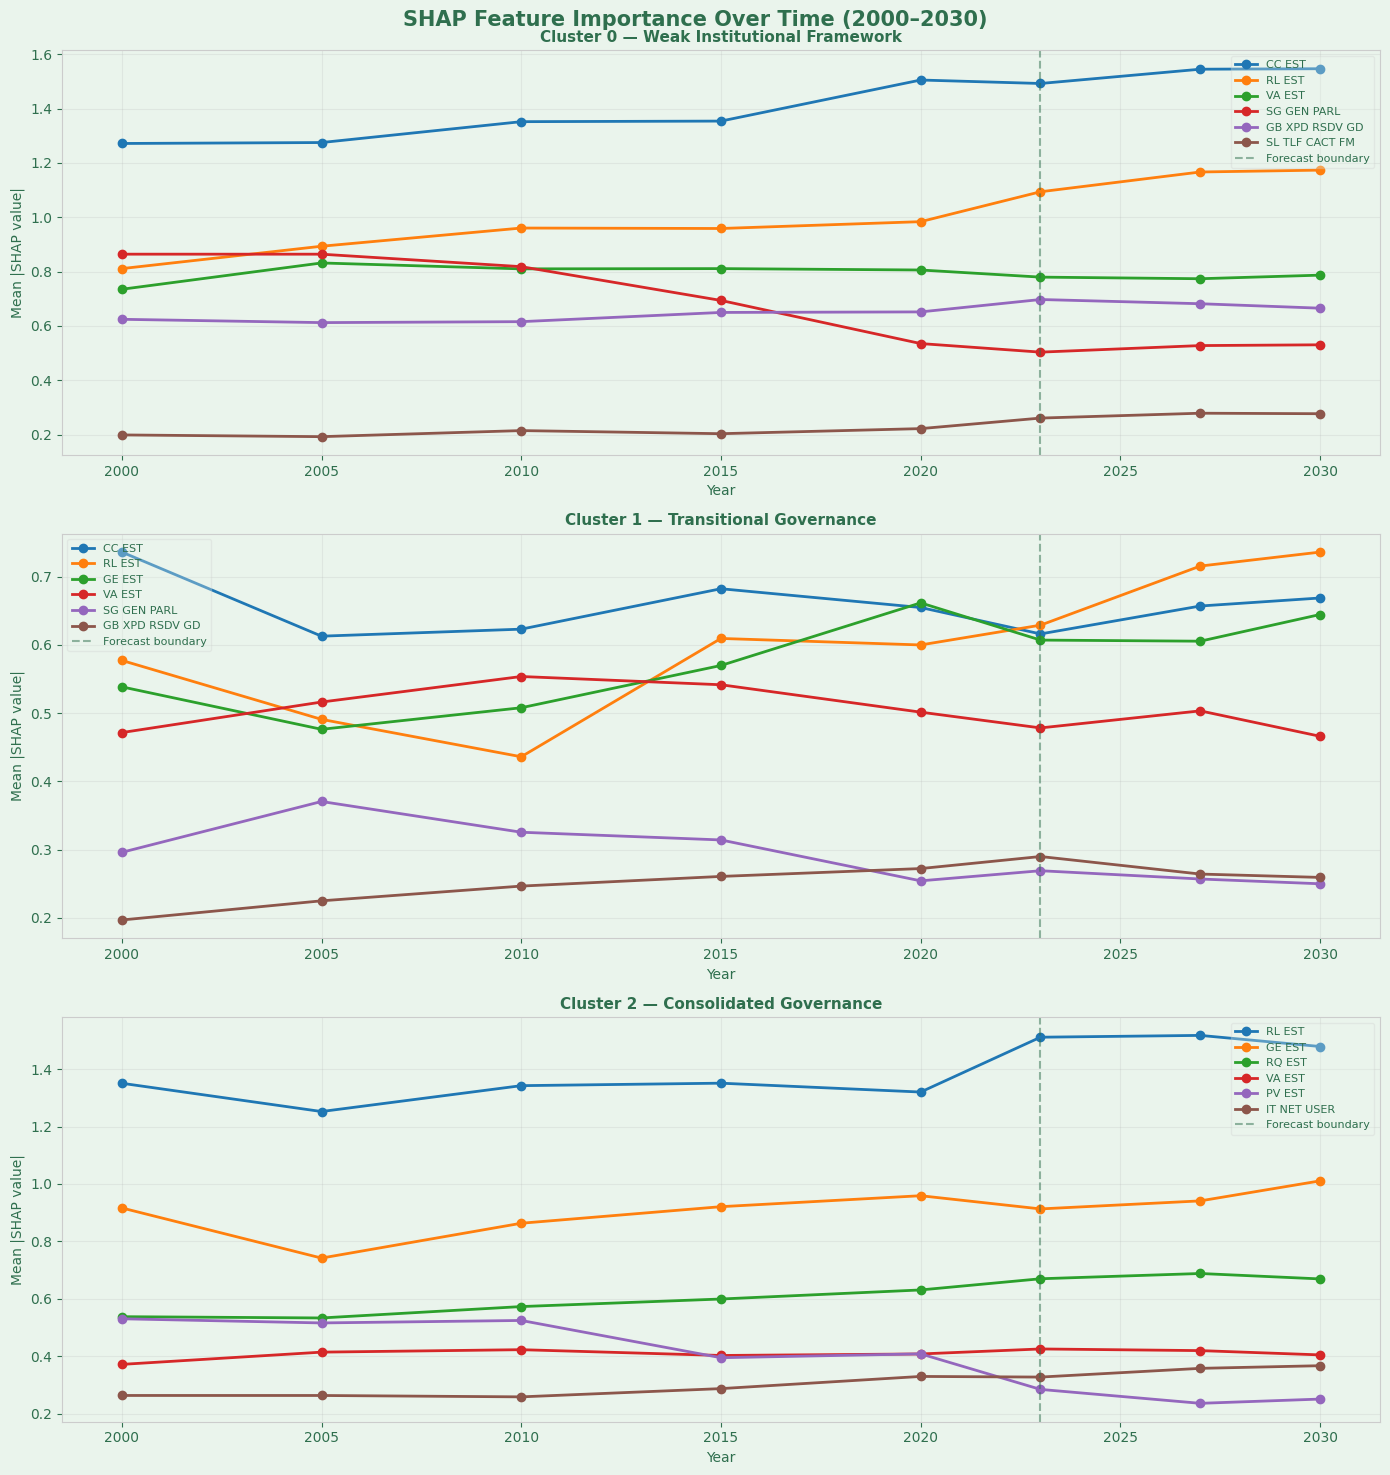

In [16]:
years_focus = [2000, 2005, 2010, 2015, 2020, 2023, 2027, 2030]
top_n = 6

shap_temporal = {k: {} for k in range(3)}

for yr in years_focus:
    mask   = df_model["year"] == yr
    if mask.sum() == 0: continue
    idx_yr = [df_model.index.get_loc(i) for i in df_model[mask].index]
    for k in range(3):
        shap_temporal[k][yr] = np.abs(shap_list[k][idx_yr]).mean(axis=0)

fig, axes = plt.subplots(3, 1, figsize=(14, 15), facecolor=BG)

for k, ax in enumerate(axes):
    df_temp      = pd.DataFrame(shap_temporal[k], index=feature_names_clean).T
    top_features = df_temp.mean().nlargest(top_n).index

    for feat in top_features:
        ax.plot(df_temp.index, df_temp[feat],
                marker="o", linewidth=2, label=feat)

    ax.axvline(x=2023, color=TEXT, linestyle="--", alpha=0.5, label="Forecast boundary")
    ax.set_title(cluster_titles[k], fontsize=11, fontweight="bold", color=TEXT)
    ax.set_xlabel("Year"); ax.set_ylabel("Mean |SHAP value|")
    ax.grid(alpha=0.2); ax.legend(fontsize=8, framealpha=0.3)

plt.suptitle("SHAP Feature Importance Over Time (2000–2030)",
             fontsize=15, fontweight="bold", color=TEXT)
plt.tight_layout()
plt.show()